# 1.1 - CNN Traning and Evaluation
The Analysis fase began. We intended to have the Brazilian states coded and its information are image type. This notebook infers in this (Brazilian) state images in order to obtain its numeric code. Therefore, this indered code could be use in clasificaion or regration models as any other tabular information.

## 1: Dependencies and Imports

In [1]:
# Standard library
import os

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset

## 2: Load Data

In [2]:
# Data load and preparation
print("Loading generated datasets...")

# Load the PyTorch files created in the previous stage
train_data = torch.load('../data/MNIST_2DIGITS/train_2digits.pt')
test_data = torch.load('../data/MNIST_2DIGITS/test_2digits.pt')

# Accessing the tensors using keys from the saved dictionary
X_train, y_train = train_data['images'], train_data['labels']
X_test, y_test = test_data['images'], test_data['labels']

# Wrap tensors in a Dataset and create DataLoaders for batch processing
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Using a batch size of 64 to optimize training stability and speed
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Data preparation complete. Training batches: {len(train_loader)}")

Loading generated datasets...
Data preparation complete. Training batches: 938


## 3: Model Definition (CNN)
A Convolutional Neural Networks is used to infer numeric images. It'll be trained with MNIST custom double digit database

In [3]:
# Model Architecture Definition
class SimpleCNN(nn.Module):
    """
    CNN architecture designed to process concatenated 28x28 MNIST digits (28x56).
    """
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        # Convolutional layers for feature extraction
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        
        # Utility layers
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        
        # Linear layers for classification
        # Input size 28x56 is reduced twice by MaxPool to 7x14
        # Flattened features: 32 filters * 7 * 14 = 3136
        self.fc1 = nn.Linear(in_features=3136, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=100)

    def forward(self, x):
        # Feature extraction block
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        
        # Flatten the feature maps for the fully connected layers
        x = x.view(x.size(0), -1) 
        
        # Classification block
        x = self.relu(self.fc1(x))
        x = self.fc2(x) 
        return x

## 4: CNN Training

In [4]:
# Configure the training components

# Instantiate the model
model = SimpleCNN()

# Standard loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer for efficient weight adjustment and faster convergence
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [5]:
# Training loop

epochs = 5  # Five epochs are sufficient for this specific classification task

print("\nStarting training...")
for epoch in range(epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        # 1. Reset gradients
        optimizer.zero_grad()
        
        # 2. Forward pass: compute predicted outputs by passing inputs to the model
        outputs = model(inputs)
        
        # 3. Calculate the loss
        loss = criterion(outputs, labels)
        
        # 4. Backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        
        # 5. Perform a single optimization step (parameter update)
        optimizer.step()
        
        running_loss += loss.item()
    
    # Calculate and display average loss per epoch
    average_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} completed. Average loss: {average_loss:.4f}")

print("Training complete.")


Starting training...
Epoch 1/5 completed. Average loss: 0.4476
Epoch 2/5 completed. Average loss: 0.1051
Epoch 3/5 completed. Average loss: 0.0661
Epoch 4/5 completed. Average loss: 0.0476
Epoch 5/5 completed. Average loss: 0.0354
Training complete.


## 5 CNN Inference and Evaluation
Infering test subset in order to study CNN's performance

In [6]:
# Test set inference

# Set the model to evaluation mode
model.eval()

all_preds = []
all_labels = []

print("Performing inference on test data...")

# Disable gradient calculation to improve speed and reduce memory consumption
with torch.no_grad():
    for images, labels in test_loader:
        # Forward pass to get scores for all 100 classes
        outputs = model(images)
        
        # Select the index with the highest score as the prediction
        _, preds = torch.max(outputs, 1)
        
        # Store predictions and ground truth for evaluation
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

Performing inference on test data...


In [7]:
# Accuracy calculation

# Calculate accuracy by comparing ground truth with model predictions
accuracy = accuracy_score(all_labels, all_preds)

print("\nFinal Results:")
print(f"Total images evaluated: {len(all_labels)}")
print(f"Model Accuracy: {accuracy * 100:.2f}%")


Final Results:
Total images evaluated: 10000
Model Accuracy: 97.80%


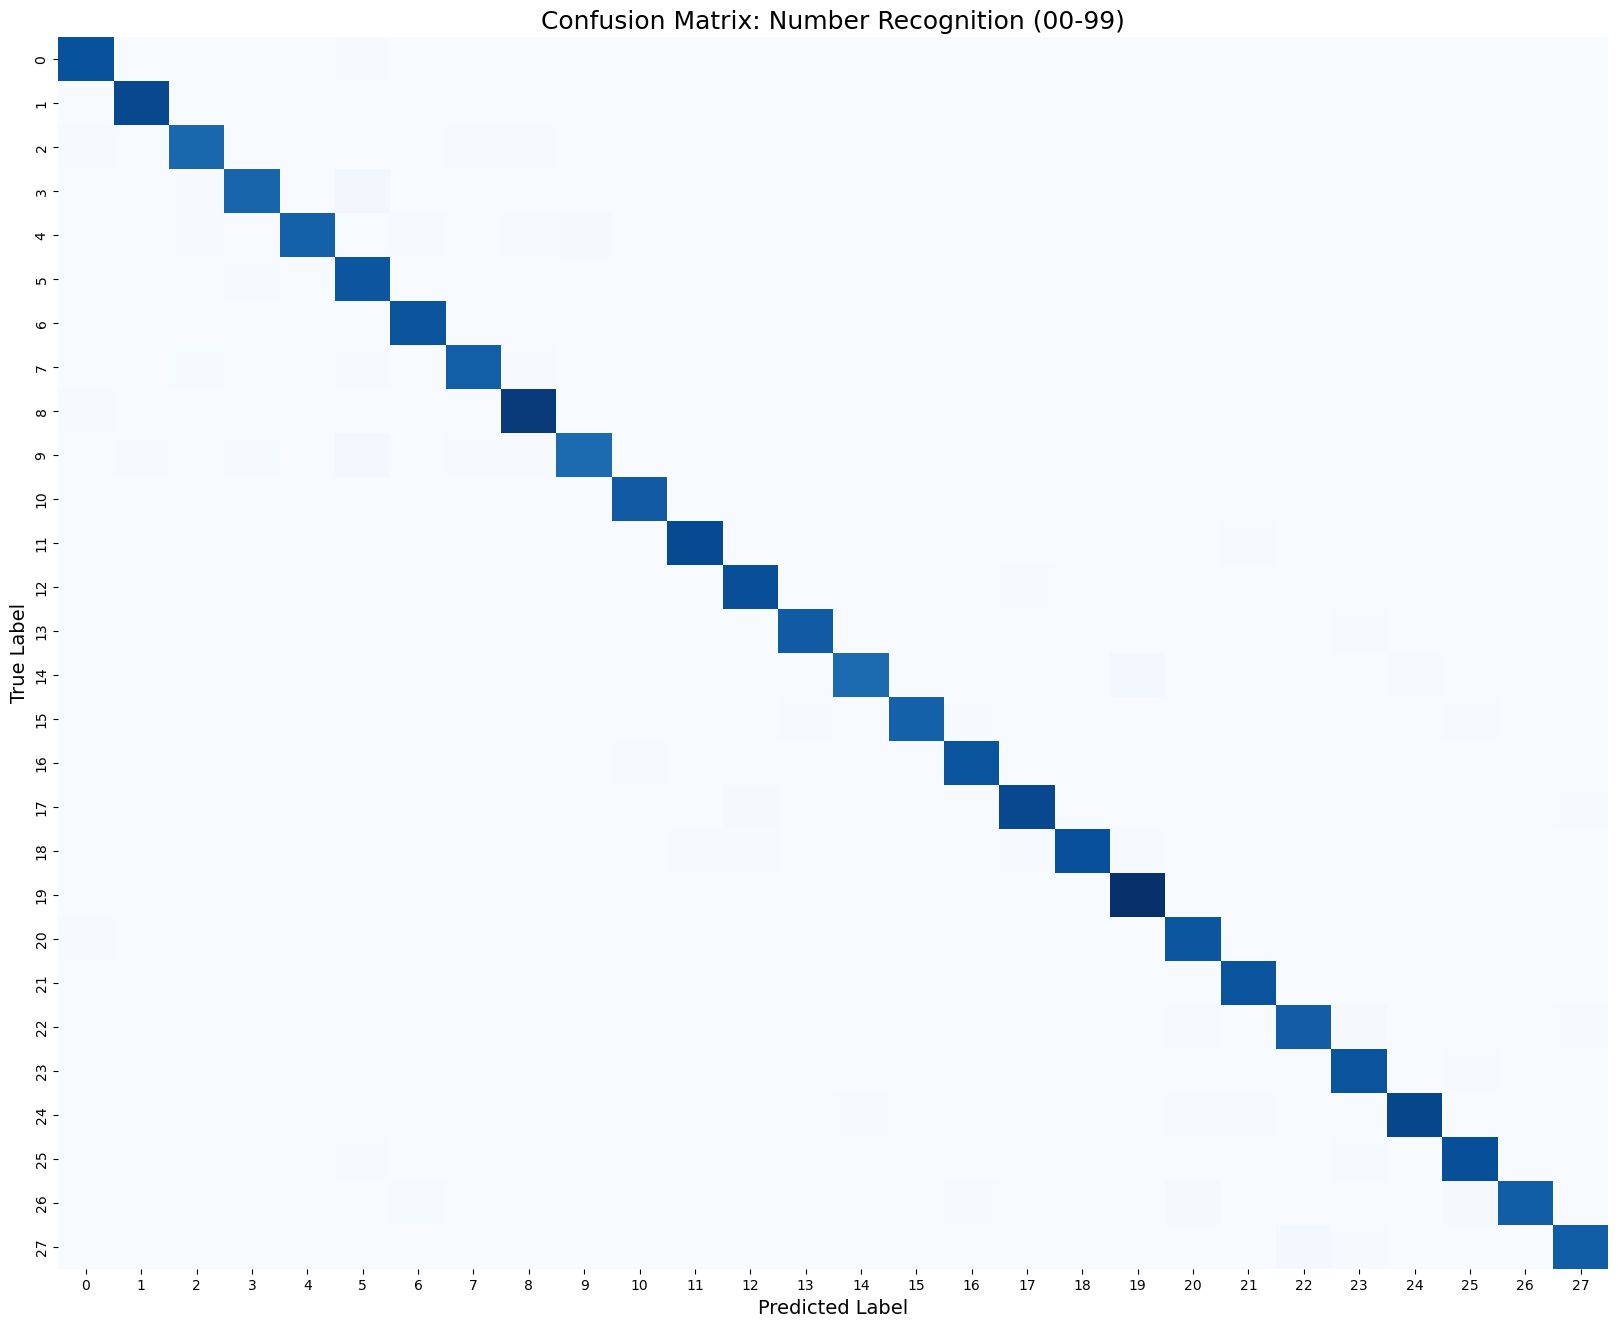


Generating visual examples of predictions...


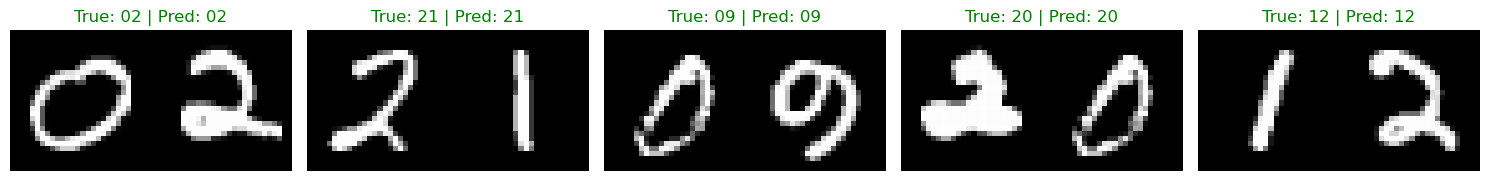

In [8]:
# Ressults visualization

# Generate the confusion matrix for all 100 classes (00-99)
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20, 16))
# Use a heatmap to visualize the distribution of errors
sns.heatmap(cm, cmap="Blues", cbar=False)
plt.title("Confusion Matrix: Number Recognition (00-99)", fontsize=18)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.show()

# Visualize random samples to compare predictions vs. ground truth
print("\nGenerating visual examples of predictions...")
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    # Select a random index from the test set
    idx = np.random.randint(0, len(all_labels))
    img = X_test[idx].squeeze().numpy()
    true_label = all_labels[idx]
    pred_label = all_preds[idx]
    
    axes[i].imshow(img, cmap='gray')
    
    # Use green text for correct predictions and red for errors
    text_color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"True: {true_label:02d} | Pred: {pred_label:02d}", color=text_color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Accuracy should be at least 95% and the confusion matrix must be almost diagonal.

## 6: Model Saving

In [9]:
# Saving the model

# Create a directory for model storage
os.makedirs('../models', exist_ok=True)

# Define the file path (standard extensions are .pth or .pt)
save_path = '../models/simple_cnn_2digits.pth'

# Save the learned parameters (state_dict)
torch.save(model.state_dict(), save_path)

print(f"Model successfully saved at: {save_path}")

Model successfully saved at: ../models/simple_cnn_2digits.pth
